In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('customer_sales_data.csv')
df.head()

,Customer_ID,Gender,Age,Region,Product_Category,Units_Purchased,Price_Per_Unit,Purchase_Date,Total_Amount
0,CUST1089,Male,50.0,NaN,Books,3,319.98,2024-11-14,959.94
1,CUST1127,male,18.0,South,Beauty,7,330.27,2024-01-23,2311.89
2,CUST1046,Female,19.0,North,Furniture,9,NaN,2024-10-17,NaN
3,CUST1012,NaN,68.0,EAST,Electronics,7,89.41,2024-08-23,625.87
4,CUST1053,male,50.0,West,Clothing,3,138.36,2024-05-06,415.08


In [26]:
# column names
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')

In [27]:
# data dtypes
df.dtypes

Customer_ID             str
Gender                  str
Age                 float64
Region                  str
Product_Category        str
Units_Purchased       int64
Price_Per_Unit      float64
Purchase_Date           str
Total_Amount        float64
dtype: object

In [28]:
# shape
df.shape

(154, 9)

# Data Preprocessing

In [29]:
df.isnull().sum()

Customer_ID         0
Gender              6
Age                 4
Region              6
Product_Category    0
Units_Purchased     0
Price_Per_Unit      5
Purchase_Date       0
Total_Amount        6
dtype: int64

In [30]:
df['Gender'].unique()

<StringArray>
['Male', 'male', 'Female', nan, 'M', 'female', 'F']
Length: 7, dtype: str

In [31]:
df['Gender'] = df['Gender'].replace(('M','male'),'Male')

In [32]:
df['Gender'] = df['Gender'].replace(('F','female'),'Female')

In [33]:
df['Gender'].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [39]:
df = df.dropna(subset=['Gender'])

In [42]:
df['Age'].unique()

array([50., 18., 19., 20., 60., 23., 43., 38., 68., 42., 21., 33., 65.,
       27., 46., 28., 25., 29., 56., 41., 67., nan, 26., 44., 57., 45.,
       36., 64., 53., 48., 47., 52., 66., 31., 34., 61., 40., 35., 39.,
       58., 54., 59., 62., 69., 24., 55., 22., 63.])

In [43]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [46]:
df['Region'].unique()

<StringArray>
[nan, 'South', 'North', 'West', 'South ', 'EAST', 'north', 'East']
Length: 8, dtype: str

In [47]:
df['Region']  = df['Region'].replace('north','North')
df['Region'] = df['Region'].replace('EAST','East')

df = df.dropna(subset=['Region'])

In [50]:
df['Price_Per_Unit'].unique()

array([330.27,    nan, 138.36, 380.13, 263.51, 297.49, 386.63, 119.29,
       276.25, 453.52, 341.95, 151.66, 249.48,  92.08, 186.4 , 134.04,
        79.61, 202.26, 455.11, 357.11,  52.23, 160.61, 419.67, 253.25,
       150.33, 171.59, 208.62, 446.82,  33.81, 409.92, 197.4 , 289.86,
       108.41, 129.18, 381.59, 332.95, 349.53, 292.44, 323.43, 331.8 ,
       382.  , 244.99, 411.11,  73.48, 498.15, 304.95, 170.19,  20.56,
        84.6 , 195.78, 280.62, 177.86, 187.05, 204.9 , 428.88, 200.47,
       497.3 , 231.35, 150.75, 175.81, 306.95, 113.29, 200.6 ,  45.03,
       474.7 , 128.87, 448.57, 253.83, 472.4 , 442.33, 288.28, 107.93,
         8.44,  54.49,  91.79, 333.43, 411.22, 498.88, 327.28, 334.63,
        51.52, 123.69,  11.97, 190.43, 178.29, 260.57, 164.66, 287.37,
       464.52, 326.73, 131.82, 155.6 , 124.82, 155.12, 194.55,  72.63,
        27.99, 368.86, 286.42, 319.37, 288.14, 425.77, 318.6 , 301.34,
       139.71, 347.49, 450.71, 137.9 , 361.87, 194.32, 327.19, 426.21,
      

In [51]:
df['Price_Per_Unit'] = df['Price_Per_Unit'].fillna(df['Price_Per_Unit'].median())

In [53]:
df.isnull().sum()

Customer_ID         0
Gender              0
Age                 0
Region              0
Product_Category    0
Units_Purchased     0
Price_Per_Unit      0
Purchase_Date       0
Total_Amount        6
dtype: int64

In [54]:
df['Total_Amount'].unique()

array([2311.89,     nan,  415.08, 1140.39, 1317.55,  892.47, 2706.41,
        596.45, 2486.25, 2721.12, 1025.85, 1364.94,  828.72,  745.6 ,
        268.08,   79.61, 1011.3 ,  682.66,  357.11,  104.46,  160.61,
        839.34, 1772.75, 1052.31,  514.77,  834.48, 1787.28,  169.05,
       3689.28,  987.  , 1159.44,  867.28,  904.26, 1144.77,  665.9 ,
       2097.18, 1169.76,  970.29, 2674.  , 2204.91, 1233.33,  514.36,
        996.3 ,  304.95, 1361.52,   61.68,  169.2 ,  391.56,  561.24,
       1600.74, 1122.3 , 1844.1 , 1286.64, 1603.76,  497.3 , 1156.75,
        603.  ,  879.05, 2148.65,  679.74,  401.2 , 3149.92,  225.15,
        949.4 ,  773.22,  507.66, 3306.8 , 2211.65, 1441.4 ,   25.32,
        163.47,  367.16, 3000.87, 1233.66,  498.88, 4581.92, 2677.04,
        103.04,  247.38,   95.76,  761.72,  356.58,  521.14,  329.32,
       2298.96, 2322.6 ,  395.46,  155.6 ,  748.92,  930.72,  291.83,
         72.63,  251.91, 2950.88,  550.53, 2577.78, 1916.22,  864.42,
       2980.39, 1365

In [55]:
df['Total_Amount'] = df['Total_Amount'].fillna(df['Total_Amount'].median())

In [56]:
df.isnull().sum()

Customer_ID         0
Gender              0
Age                 0
Region              0
Product_Category    0
Units_Purchased     0
Price_Per_Unit      0
Purchase_Date       0
Total_Amount        0
dtype: int64

In [57]:
df.shape

(142, 9)

In [60]:
# Convert Purchase_Date to datetime.
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'],format='mixed')

In [65]:
#  Using NumPy to:
# Calculate average Total_Amount and Units_Purchased.
# Find the highest and lowest purchase amount.

np.mean(df['Total_Amount'])

np.float64(1193.8816901408452)

In [68]:
np.mean(df['Units_Purchased'])

np.float64(4.514084507042254)

In [69]:
max_purchase = np.argmax(df['Total_Amount'])
print(max_purchase)

80


In [70]:
min_purchased = np.argmin(df['Total_Amount'])
print(min_purchased)

141


In [ ]:
# Group total sales by:
# Gender
# Region
# Product Category

In [71]:
df['Total_Sales'] = df['Total_Amount'].sum()
df['Total_Sales']

1      169531.2
2      169531.2
4      169531.2
5      169531.2
6      169531.2
         ...   
148    169531.2
150    169531.2
151    169531.2
152    169531.2
153    169531.2
Name: Total_Sales, Length: 142, dtype: float64

In [72]:
df.groupby(['Gender', 'Region', 'Product_Category'])['Total_Amount'].sum()

Gender  Region  Product_Category
Female  East    Beauty              2322.60
                Books               3689.84
                Clothing            8679.58
                Electronics         1829.72
                Furniture           8559.64
                                     ...   
Male    West    Clothing            3395.47
                Electronics         2486.25
                Furniture           2323.29
                Grocery              745.60
                Sports              2870.81
Name: Total_Amount, Length: 65, dtype: float64

In [73]:
df.head(2)

,Customer_ID,Gender,Age,Region,Product_Category,Units_Purchased,Price_Per_Unit,Purchase_Date,Total_Amount,Total_Sales
1,CUST1127,Male,18.0,South,Beauty,7,330.27,2024-01-23,2311.89,169531.2
2,CUST1046,Female,19.0,North,Furniture,9,253.25,2024-10-17,957.35,169531.2


In [76]:
# Show month-wise or weekly total purchases using Purchase_Date.
df['Month'] = df['Purchase_Date'].dt.month


In [79]:
df['Week'] = df['Purchase_Date'].dt.weekday

In [84]:
df.groupby('Month')['Total_Amount'].sum()

Month
1     13473.57
2     19293.50
3     15996.89
4     12406.74
5      9254.93
6      7251.26
7     16473.22
8     15952.88
9     12312.86
10    19962.23
11    10118.10
12    17035.02
Name: Total_Amount, dtype: float64

In [85]:
df.groupby('Week')['Total_Amount'].sum()

Week
0    32954.16
1    20861.40
2    22738.47
3    27584.08
4    16245.50
5    26632.39
6    22515.20
Name: Total_Amount, dtype: float64

# Visualization

### Total sales by Product Category

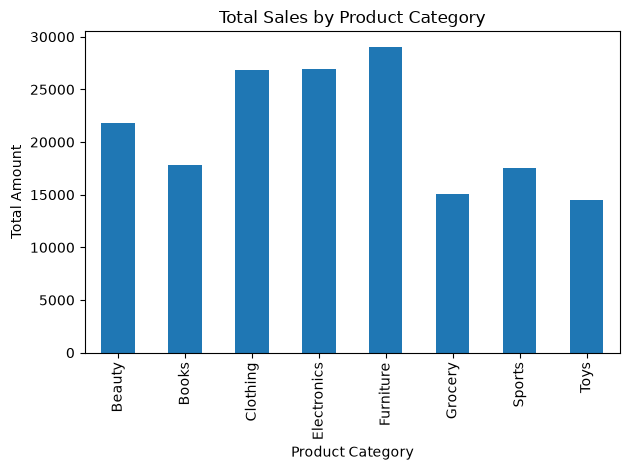

In [87]:
df.groupby('Product_Category')['Total_Amount'].sum().plot(kind='bar')
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.title("Total Sales by Product Category")
plt.tight_layout()
plt.show()

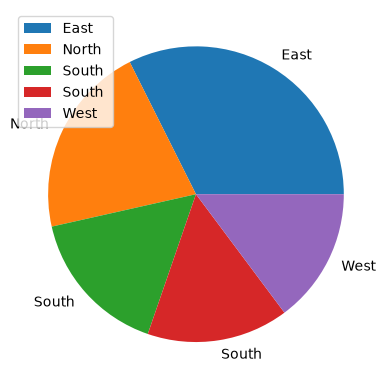

In [93]:
df.groupby('Region')['Customer_ID'].count().plot(kind='pie')
plt.legend()
plt.ylabel('') 
plt.show()

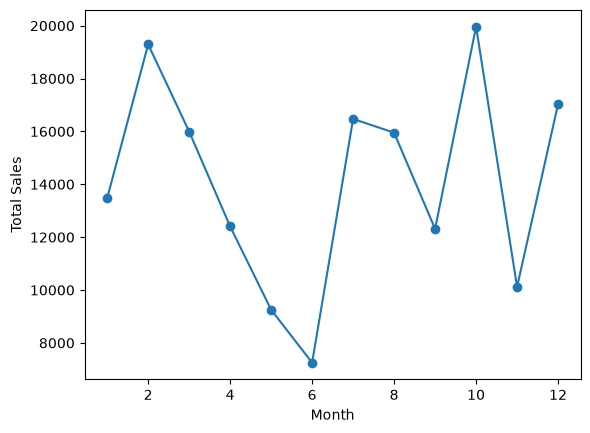

In [96]:
df.groupby('Month')['Total_Amount'].sum().plot(kind='line',marker='o')
plt.ylabel('Total Sales')
plt.show()


# Seaborn 

### Create a box plot of Total_Amount by Gender.

In [98]:
import seaborn as sns

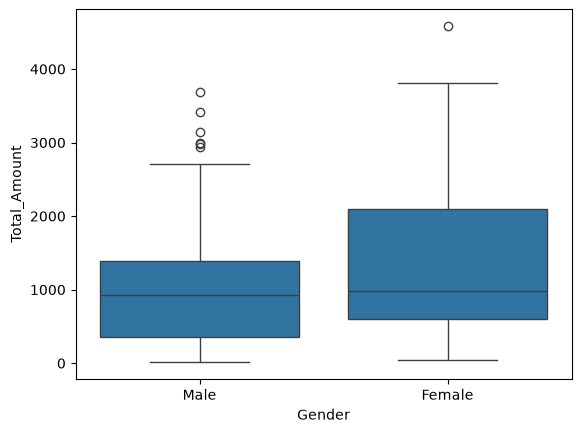

In [101]:
sns.boxplot(x='Gender', y='Total_Amount', data=df)
plt.show()

In [104]:
numeric_cols = df[['Age', 'Units_Purchased', 'Price_Per_Unit', 'Total_Amount']]
corr_matrix = numeric_cols.corr()
print(corr_matrix)

                      Age  Units_Purchased  Price_Per_Unit  Total_Amount
Age              1.000000        -0.143157        0.072937      0.033939
Units_Purchased -0.143157         1.000000        0.000564      0.427762
Price_Per_Unit   0.072937         0.000564        1.000000      0.613459
Total_Amount     0.033939         0.427762        0.613459      1.000000


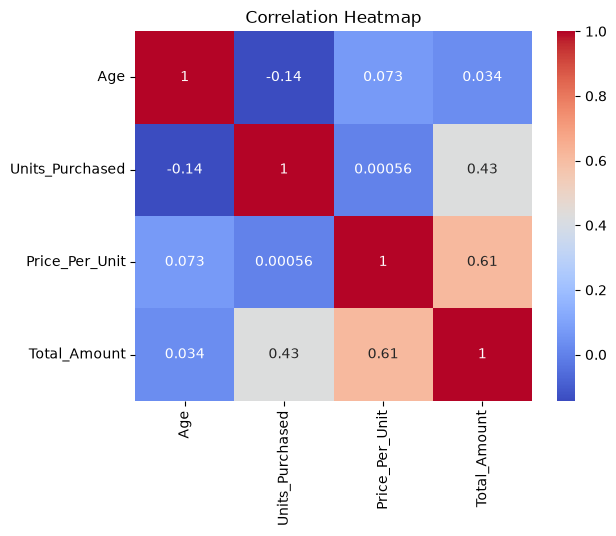

In [105]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()